In [16]:
# Manipulacao e visualizacao dos dados
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
  mean_absolute_error,
  r2_score,
  mean_absolute_percentage_error,
)

In [17]:
# Importa o conjunto de dados
df = pd.read_csv(r"data/historico_vendas.csv", index_col="TS", parse_dates=True)

# Visualizacao dos dados
df

,Sales
TS,
2016-12-31,41738
2017-12-31,46370
2018-12-31,52052
2019-12-31,60192
2020-12-31,64447
2021-12-31,68561
2022-12-31,60079
2023-12-31,67687


In [18]:
# Criar modelo de regressao linear

# Variavel independente (anos)
X = df.index.year.values.reshape(-1, 1)

# Variavel dependente (vendas)
y = df["Sales"].values

# Treinar o modelo
modelo = LinearRegression().fit(X, y)

In [19]:
# Gerar historico de previsoes
anos_passado = X.copy()
previsoes_passado = modelo.predict(anos_passado)

# prever vendas para os proximos 3 anos
anos_futuro = np.array([[2024], [2025], [2026]])
previsoes_futuro = modelo.predict(anos_futuro.reshape(-1, 1))

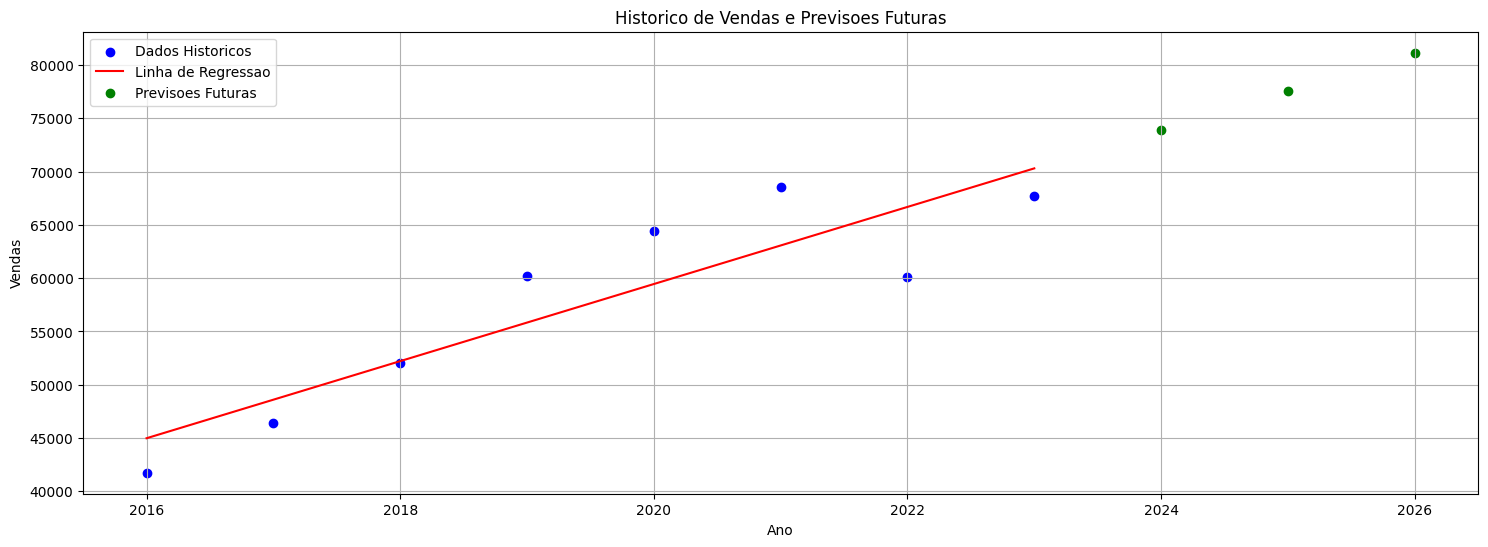

In [20]:
# Visualizar os resultados
plt.figure(figsize=(18, 6))


# Dados historicos (graficos de dispersao)
plt.scatter(X, y, color="blue", label="Dados Historicos")

# Linha de regressao (previsoes do passado)
plt.plot(anos_passado, previsoes_passado, color="red", label="Linha de Regressao")

# Dados previstos (graficos de dispersao)
plt.scatter(anos_futuro, previsoes_futuro, color="green", label="Previsoes Futuras")

plt.xlabel("Ano")
plt.ylabel("Vendas")
plt.title("Historico de Vendas e Previsoes Futuras")
plt.legend()
plt.grid()         
plt.show()

In [ ]:
# Calcular metricas de desempenho
r2_regressao = r2_score(y_true=y, y_pred=previsoes_passado) # Quanto seu modelo explica da variancia dos dados
mae_regressao = mean_absolute_error(y_true=y, y_pred=previsoes_passado) # Erro absoluto medio
mape_regressao = mean_absolute_percentage_error(y_true=y, y_pred=previsoes_passado) # Erro percentual medio

print(f"R² da Regressao Linear: {r2_regressao * 100:.2f}%")
print(f"MAE da Regressao Linear: {mae_regressao:.4f}")
print(f"MAPE da Regressao Linear: {mape_regressao * 100:.2f}%")

R² da Regressao Linear: 0.7969
MAE da Regressao Linear: 3712.4286
MAPE da Regressao Linear: 6.34%
